## IMPORTS

In [13]:
import requests
from bs4 import BeautifulSoup
import json
import re
import time
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import pandas as pd

## ***Custom Urdu Tokenizer***

The tokenizer must handle:
- Word boundaries
- Punctuation
- Postpositions
- Numbers and special tokens

All numbers must be replaced with `<NUM>`.

Input:

پاکستان میں میں بارش ہوئی  
2024  

Output:

پاکستان | میں | میں | بارش | ہوئی  
`<NUM>`

In [14]:

punctuation_marks = '۔،؟!'

def urdu_tokenizer(text):
    tokens = []
    current = ''

    for ch in text:
        if ch in punctuation_marks:
            if current:
                tokens.append(current)
                current = ''
            tokens.append(ch)
        elif ch.isspace():
            if current:
                tokens.append(current)
                current = ''
        else:
            current += ch

    if current:
        tokens.append(current)

    return tokens


## ***Custom Urdu Stemmer***
The stemmer must remove common Urdu suffixes.

Input:
لڑکیوں نے کتابیں پڑھیں  

Output:
لڑکی | کتاب | پڑھ

Custom Urdu stemmer with correct suffix handling (3 Marks)


In [15]:

common_suffixes = [
    'یاں', 'وں', 'یں', 'ات', 'گی', 'گا', 'نے', 'کو', 'سے', 'پر'
]

def urdu_stemmer(word):
    for suf in common_suffixes:
        if word.endswith(suf) and len(word) > len(suf) + 2:
            return word[:-len(suf)]
    return word


In [16]:
def stem_tokens(tokens):
    return [urdu_stemmer(token) for token in tokens]


## ***Custom Urdu Lemmatizer***

The lemmatizer is restricted to:
- Plural normalization
- Gender normalization

Plural:
- لڑکیاں -> لڑکی  
- کتابوں -> کتاب  

Gender:
- اچھی -> اچھا  
- بڑی -> بڑا

Custom Urdu lemmatizer for plural and gender normalization (3 Marks)

In [17]:
lemma_mapping ={
    'لڑکیاں': 'لڑکی',
    'لڑکے': 'لڑکا',
    'عورتیں': 'عورت',
    'مردوں': 'مرد',
    'بچوں': 'بچہ',
    'لوگوں': 'لوگ',
    'کتابیں': 'کتاب',
    'کرسیاں': 'کرسی',
    'آنکھوں': 'آنکھ',
    'ہاتھوں': 'ہاتھ',
    'باتیں': 'بات',
    'راتوں': 'رات',
    'دروازوں': 'دروازہ',
    'گھروں': 'گھر',
    'شہروں': 'شہر',
    'کھاتا': 'کھا',
    'کھاتی': 'کھا',
    'کھاتے': 'کھا',
    'پیتا': 'پی',
    'پیتے': 'پی',
    'سوتا': 'سو',
    'سوتے': 'سو',
    'کرتا': 'کر',
    'کرتی': 'کر',
    'کرتے': 'کر',
    'ہوا': 'ہو',
    'ہوئی': 'ہو',
    'ہوئے': 'ہو',
    'گیا': 'جا',
    'گئی': 'جا',
    'گئے': 'جا',
    'آیا': 'آ',
    'آئی': 'آ',
    'آئے': 'آ',
    'اچھے': 'اچھا',
    'اچھی': 'اچھا',
    'بڑے': 'بڑا',
    'بڑی': 'بڑا',
    'چھوٹے': 'چھوٹا',
    'چھوٹی': 'چھوٹا',
    'لمبے': 'لمبا',
    'لمبی': 'لمبا'

}

In [18]:
def urdu_lemmatizer(word):
    return lemma_mapping .get(word, word)


In [109]:
def lemmatize_tokens(tokens):
    return [urdu_lemmatizer(token) for token in tokens]

In [106]:
# Apply heuristic POS and NER tags to the DataFrame
df['pos_tags'] = df['tokens'].apply(assign_pos_tags)
df['ner_tags'] = df['tokens'].apply(assign_ner_tags)

# Get all unique POS and NER tags
all_pos_tags = sorted(list(set(tag for sublist in df['pos_tags'] for tag in sublist)))
pos_to_idx = {tag: i for i, tag in enumerate(all_pos_tags)}
idx_to_pos = {i: tag for tag, i in pos_to_idx.items()}

all_ner_tags = sorted(list(set(tag for sublist in df['ner_tags'] for tag in sublist)))
ner_to_idx = {tag: i for i, tag in enumerate(all_ner_tags)}
idx_to_ner = {i: tag for tag, i in ner_to_idx.items()}

print(f"Unique POS Tags: {all_pos_tags}")
print(f"Unique NER Tags: {all_ner_tags}")

# Convert tags to numerical IDs
df['pos_ids'] = df['pos_tags'].apply(lambda tags: [pos_to_idx[tag] for tag in tags])
df['ner_ids'] = df['ner_tags'].apply(lambda tags: [ner_to_idx[tag] for tag in tags])

Unique POS Tags: ['ADV', 'CONJ', 'DET', 'NOUN', 'POST', 'PRON', 'VERB']
Unique NER Tags: ['B-LOC', 'B-ORG', 'B-PER', 'O']


In [103]:
# Apply heuristic POS and NER tags to the DataFrame
df['pos_tags'] = df['tokens'].apply(assign_pos_tags)
df['ner_tags'] = df['tokens'].apply(assign_ner_tags)

# Get all unique POS and NER tags
all_pos_tags = sorted(list(set(tag for sublist in df['pos_tags'] for tag in sublist)))
pos_to_idx = {tag: i for i, tag in enumerate(all_pos_tags)}
idx_to_pos = {i: tag for tag, i in pos_to_idx.items()}

all_ner_tags = sorted(list(set(tag for sublist in df['ner_tags'] for tag in sublist)))
ner_to_idx = {tag: i for i, tag in enumerate(all_ner_tags)}
idx_to_ner = {i: tag for tag, i in ner_to_idx.items()}

print(f"Unique POS Tags: {all_pos_tags}")
print(f"Unique NER Tags: {all_ner_tags}")

# Convert tags to numerical IDs
df['pos_ids'] = df['pos_tags'].apply(lambda tags: [pos_to_idx[tag] for tag in tags])
df['ner_ids'] = df['ner_tags'].apply(lambda tags: [ner_to_idx[tag] for tag in tags])

Unique POS Tags: ['ADV', 'CONJ', 'DET', 'NOUN', 'POST', 'PRON', 'VERB']
Unique NER Tags: ['B-LOC', 'B-ORG', 'B-PER', 'O']


In [20]:

ARTICLE_SPLIT_PATTERN = r'(\[\d+\])'

def load_articles(path="cleaned.txt"):
    with open(path, "r", encoding="utf-8") as f:
        content = f.read()

    parts = re.split(ARTICLE_SPLIT_PATTERN, content)

    articles = []
    i = 1
    while i < len(parts):
        article_id = parts[i].strip()
        text = parts[i + 1].strip()
        articles.append((article_id, text))
        i += 2

    return articles


In [21]:
def build_dataframe(articles):
    data = []

    for article_id, text in articles:
        tokens = urdu_tokenizer(text)
        stems = stem_tokens(tokens)
        lemmas = lemmatize_tokens(tokens)

        data.append({
            "article_id": article_id,
            "original_text": text,
            "tokens": tokens,
            "stems": stems,
            "lemmas": lemmas
        })

    df = pd.DataFrame(data)
    return df


In [22]:
def save_dataset(lines, path):
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))


In [23]:
articles = load_articles("cleaned.txt")
df = build_dataframe(articles)
print(len(df))

307


In [24]:
df['topic'] = 'sports'
print("All articles are from sports topic.")

All articles are from sports topic.


# **Part 1 Word Embeddings**

1. TF-IDF and PMI Weighted Representations

Vocabulary (top-10k + <UNK>)

In [25]:
from collections import Counter

MAX_VOCAB = 10_000

def build_vocab(df):
    counter = Counter()

    for tokens in df["tokens"]:
        counter.update(tokens)

    most_common = counter.most_common(MAX_VOCAB)
    vocab = {w: i+1 for i, (w, _) in enumerate(most_common)}
    vocab["<UNK>"] = 0

    idx2word = {i: w for w, i in vocab.items()}
    return vocab, idx2word, counter
vocab, idx2word, counter = build_vocab(df)
print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 10001


Term–Document Matrix (TF)

In [26]:

def build_tf_matrix(df, vocab):
    N = len(df)
    V = len(vocab)
    tf = np.zeros((N, V), dtype=np.float32)

    for d, tokens in enumerate(df["tokens"]):
        for w in tokens:
            idx = vocab.get(w, 0)
            tf[d, idx] += 1

    return tf

TF-IDF

In [27]:
def build_tfidf(tf):
    N, V = tf.shape

    df_w = np.count_nonzero(tf, axis=0)
    idf = np.log(N / (1 + df_w))

    tfidf = tf * idf
    return tfidf

tf = build_tf_matrix(df, vocab)
tfidf = build_tfidf(tf)

np.save("tfidf_matrix.npy", tfidf)

Top-10 discriminative words per topic

In [28]:
def top_words_per_topic(tfidf, df, vocab, labels, k=10):
    idx2word = {i: w for w, i in vocab.items()}
    results = {}

    for topic in set(labels.values()):
        doc_ids = [i for i, a in enumerate(df["article_id"]) if labels[a] == topic]
        avg_scores = tfidf[doc_ids].mean(axis=0)

        top_idx = np.argsort(avg_scores)[-k:][::-1]
        results[topic] = [idx2word[i] for i in top_idx]

    return results


In [29]:
with open("articles.json") as f:
    articles = json.load(f)

# topics = list(set([m['topic'] for m in articles.values()])) # 'topic' key not found in articles.json data

def top_tfidf_words(tfidf, docs, vocab, topic, top_k=10):
    idxs = [i for i,d in enumerate(docs) if d['topic']==topic]
    mean_scores = tfidf[idxs].mean(axis=0)
    top_ids = np.argsort(mean_scores)[-top_k:][::-1]
    inv_vocab = {v:k for k,v in vocab.items()}
    return [inv_vocab[i] for i in top_ids]

### 1.2 Pointwise Mutual Information (PMI)



Word–Word Co-occurrence (PPMI, k=5)

In [30]:
def build_cooccurrence(df, vocab, window=5):
    V = len(vocab)
    cooc = np.zeros((V, V), dtype=np.float32)

    for tokens in df["tokens"]:
        ids = [vocab.get(w, 0) for w in tokens]

        for i, center in enumerate(ids):
            start = max(0, i - window)
            end = min(len(ids), i + window + 1)

            for j in range(start, end):
                if i != j:
                    context = ids[j]
                    cooc[center, context] += 1

    return cooc

PPMI computation

In [31]:
def compute_ppmi(cooc):
    total = cooc.sum()

    word_freq = cooc.sum(axis=1)
    P_w = word_freq / total
    P_wc = cooc / total

    ppmi = np.zeros_like(cooc)

    for i in range(cooc.shape[0]):
        for j in range(cooc.shape[1]):
            if P_wc[i, j] > 0:
                val = np.log2(P_wc[i, j] / (P_w[i] * P_w[j]))
                ppmi[i, j] = max(0, val)

    return ppmi

cooc = build_cooccurrence(df, vocab)
ppmi = compute_ppmi(cooc)

np.save("ppmi_matrix.npy", ppmi)

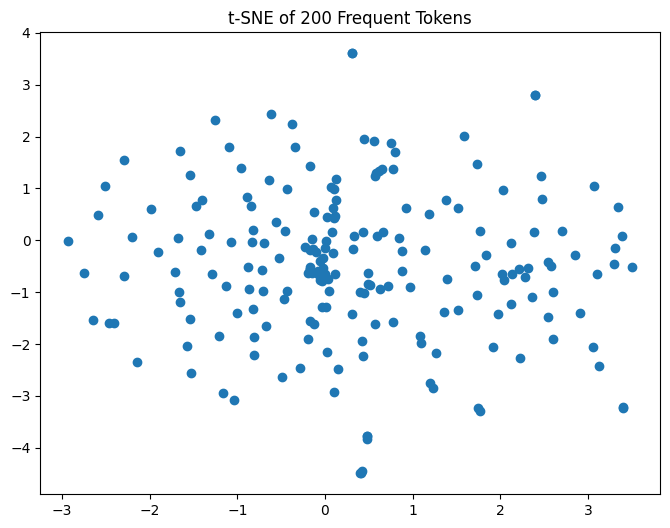

In [32]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

emb = ppmi[:200]
tsne = TSNE(n_components=2, perplexity=30)
X = tsne.fit_transform(emb)

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1])
plt.title("t‑SNE of 200 Frequent Tokens")
plt.show()

In [33]:
from sklearn.metrics.pairwise import cosine_similarity

def nearest(word, matrix, word2idx, k=5):
    idx = word2idx[word]
    sims = cosine_similarity(matrix[idx:idx+1], matrix)[0]
    top = np.argsort(sims)[-k-1:-1][::-1]
    return [inv_vocab[i] for i in top]


In [34]:
query_words = [
    'پاکستان', 'کرکٹ', 'کر', 'ٹیم', 'میچ', 'انڈیا', 'بڑی', 'اچھی', 'لوگوں', 'کتابیں'
]

inv_vocab = {v: k for k, v in vocab.items()}

print("Top 5 nearest neighbors for selected words (using PPMI embeddings):")
for word in query_words:
    if word in vocab:
        neighbors = nearest(word, ppmi, vocab, k=5)
        print(f"  '{word}': {neighbors}")
    else:
        print(f"  '{word}': Not found in vocabulary")

Top 5 nearest neighbors for selected words (using PPMI embeddings):
  'پاکستان': ['کرکٹ', 'کے', 'انڈیا', 'کا', 'میں']
  'کرکٹ': ['بورڈ', 'پاکستان', 'کے', 'ہے', 'کی']
  'کر': ['دیا', 'رہے', '۔', 'کو', 'بنا']
  'ٹیم': ['کو', 'کی', 'اور', 'انڈین', 'میں']
  'میچ': ['میں', 'خلاف', 'کے', 'ریفری', 'دوران']
  'انڈیا': ['پاکستان', 'کے', 'میں', 'انڈین', 'اور']
  'بڑی': ['سپانسرشپس', 'نمودار', 'معاہدوں', 'گاؤن', 'سکتی']
  'اچھی': ['بہت', 'کارکردگی', 'عمدہ', 'خاصی', 'بیتھیل']
  'لوگوں': ['پش', 'ترنمول', 'صارفین', 'افراد', 'دوائیں']
  'کتابیں': Not found in vocabulary


### 2. Skip-gram Word2Vec

Skip-gram training pairs (Urdu-safe)

In [35]:
def generate_skipgram_pairs(df, vocab, window=5):
    pairs = []

    for tokens in df["tokens"]:
        ids = [vocab.get(w, 0) for w in tokens]

        for i, center in enumerate(ids):
            start = max(0, i - window)
            end = min(len(ids), i + window + 1)

            for j in range(start, end):
                if i != j:
                    pairs.append((center, ids[j]))

    return pairs

Noise distribution f(w)³⁄⁴

In [36]:
def build_noise_distribution(counter, vocab):
    noise = np.zeros(len(vocab))

    for w, c in counter.items():
        idx = vocab.get(w, 0)
        noise[idx] = c ** 0.75

    noise /= noise.sum()
    return noise

In [37]:
pairs = generate_skipgram_pairs(df, vocab)
noise_dist = build_noise_distribution(counter, vocab)
print(f"Generated {len(pairs)} skip-gram pairs.")
print(f"Noise distribution built with shape: {noise_dist.shape}")

Generated 3661830 skip-gram pairs.
Noise distribution built with shape: (10001,)


Save mappings

In [38]:
import json

with open("word2idx.json", "w", encoding="utf-8") as f:
    json.dump(vocab, f, ensure_ascii=False, indent=2)

Skip-gram Word2Vec

In [39]:
import torch
from torch.utils.data import Dataset

class SkipGramDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        center, context = self.pairs[idx]
        return (
            torch.tensor(center, dtype=torch.long),
            torch.tensor(context, dtype=torch.long)
        )

Skip-gram Model

In [40]:
import torch.nn as nn

class SkipGram(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.V = nn.Embedding(vocab_size, emb_dim)
        self.U = nn.Embedding(vocab_size, emb_dim)

        nn.init.xavier_uniform_(self.V.weight)
        nn.init.xavier_uniform_(self.U.weight)

    def forward(self, center, context, negatives):
        v = self.V(center)
        u_pos = self.U(context)
        u_neg = self.U(negatives)

        pos_loss = torch.log(torch.sigmoid((v * u_pos).sum(dim=1)))
        neg_loss = torch.log(torch.sigmoid(-(v.unsqueeze(1) * u_neg).sum(dim=2))).sum(dim=1)

        return -(pos_loss + neg_loss).mean()

Training Loop

In [45]:
from torch.utils.data import DataLoader
import numpy as np

EMB_DIM = 100
K = 5
LR = 0.001
EPOCHS = 5
BATCH_SIZE = 2048

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SkipGram(len(vocab), EMB_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

noise_dist = torch.tensor(noise_dist, dtype=torch.float).to(device)

dataset = SkipGramDataset(pairs)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

losses = []

for epoch in range(EPOCHS):
    epoch_loss = 0.0

    num_samples_needed = len(dataset) * K
    all_neg_indices = torch.multinomial(noise_dist, num_samples_needed, replacement=True).view(-1, K)

    for i, (center, context) in enumerate(loader):
        center, context = center.to(device), context.to(device)
        neg_samples = all_neg_indices[i * BATCH_SIZE : (i + 1) * BATCH_SIZE]

        if neg_samples.size(0) != center.size(0):
            neg_samples = neg_samples[:center.size(0)]

        optimizer.zero_grad(set_to_none=True)
        loss = model(center, context, neg_samples)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f}")

/tmp/ipykernel_2098/587548535.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  noise_dist = torch.tensor(noise_dist, dtype=torch.float).to(device)


Epoch 1/5 - Loss: 2.6448
Epoch 2/5 - Loss: 2.4309
Epoch 3/5 - Loss: 2.3760
Epoch 4/5 - Loss: 2.3366
Epoch 5/5 - Loss: 2.3058


In [124]:
from torch.nn.utils.rnn import pad_sequence

class SequenceTaggingDataset(Dataset):
    def __init__(self, df, vocab, pos_to_idx, ner_to_idx):
        self.data = []
        for _, row in df.iterrows():
            token_ids = [vocab.get(token, vocab['<UNK>']) for token in row['tokens']]
            pos_ids = row['pos_ids']
            ner_ids = row['ner_ids']
            self.data.append((token_ids, pos_ids, ner_ids))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        token_ids, pos_ids, ner_ids = self.data[idx]
        return (
            torch.tensor(token_ids, dtype=torch.long),
            torch.tensor(pos_ids, dtype=torch.long),
            torch.tensor(ner_ids, dtype=torch.long)
        )

def collate_fn(batch):
    token_ids, pos_ids, ner_ids = zip(*batch)

    # Pad sequences to the maximum length in the batch
    token_lengths = torch.tensor([len(x) for x in token_ids], dtype=torch.long)
    padded_token_ids = pad_sequence(token_ids, batch_first=True, padding_value=vocab['<UNK>'])
    padded_pos_ids = pad_sequence(pos_ids, batch_first=True, padding_value=-1) # Use -1 for padding POS labels
    padded_ner_ids = pad_sequence(ner_ids, batch_first=True, padding_value=-1) # Use -1 for padding NER labels

    return padded_token_ids, token_lengths, padded_pos_ids, padded_ner_ids


# Prepare datasets and dataloaders

# Split data into training, validation, and test sets for sequence tagging
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_seq_dataset = SequenceTaggingDataset(train_df, vocab, pos_to_idx, ner_to_idx)
val_seq_dataset = SequenceTaggingDataset(val_df, vocab, pos_to_idx, ner_to_idx)
test_seq_dataset = SequenceTaggingDataset(test_df, vocab, pos_to_idx, ner_to_idx)

BATCH_SIZE_SEQ = 32 # Batch size for sequence tagging

train_seq_loader = DataLoader(train_seq_dataset, batch_size=BATCH_SIZE_SEQ, shuffle=True, collate_fn=collate_fn)
val_seq_loader = DataLoader(val_seq_dataset, batch_size=BATCH_SIZE_SEQ, shuffle=False, collate_fn=collate_fn)
test_seq_loader = DataLoader(test_seq_dataset, batch_size=BATCH_SIZE_SEQ, shuffle=False, collate_fn=collate_fn)

print(f"Train sequence loader has {len(train_seq_loader)} batches.")
print(f"Validation sequence loader has {len(val_seq_loader)} batches.")
print(f"Test sequence loader has {len(test_seq_loader)} batches.")

Train sequence loader has 7 batches.
Validation sequence loader has 2 batches.
Test sequence loader has 2 batches.


In [107]:
from torch.nn.utils.rnn import pad_sequence

class SequenceTaggingDataset(Dataset):
    def __init__(self, df, vocab, pos_to_idx, ner_to_idx):
        self.data = []
        for _, row in df.iterrows():
            token_ids = [vocab.get(token, vocab['<UNK>']) for token in row['tokens']]
            pos_ids = row['pos_ids']
            ner_ids = row['ner_ids']
            self.data.append((token_ids, pos_ids, ner_ids))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        token_ids, pos_ids, ner_ids = self.data[idx]
        return (
            torch.tensor(token_ids, dtype=torch.long),
            torch.tensor(pos_ids, dtype=torch.long),
            torch.tensor(ner_ids, dtype=torch.long)
        )

def collate_fn(batch):
    token_ids, pos_ids, ner_ids = zip(*batch)

    # Pad sequences to the maximum length in the batch
    token_lengths = torch.tensor([len(x) for x in token_ids], dtype=torch.long)
    padded_token_ids = pad_sequence(token_ids, batch_first=True, padding_value=vocab['<UNK>'])
    padded_pos_ids = pad_sequence(pos_ids, batch_first=True, padding_value=-1) # Use -1 for padding POS labels
    padded_ner_ids = pad_sequence(ner_ids, batch_first=True, padding_value=-1) # Use -1 for padding NER labels

    return padded_token_ids, token_lengths, padded_pos_ids, padded_ner_ids


# Prepare datasets and dataloaders

# Split data into training, validation, and test sets for sequence tagging
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_seq_dataset = SequenceTaggingDataset(train_df, vocab, pos_to_idx, ner_to_idx)
val_seq_dataset = SequenceTaggingDataset(val_df, vocab, pos_to_idx, ner_to_idx)
test_seq_dataset = SequenceTaggingDataset(test_df, vocab, pos_to_idx, ner_to_idx)

BATCH_SIZE_SEQ = 32 # Batch size for sequence tagging

train_seq_loader = DataLoader(train_seq_dataset, batch_size=BATCH_SIZE_SEQ, shuffle=True, collate_fn=collate_fn)
val_seq_loader = DataLoader(val_seq_dataset, batch_size=BATCH_SIZE_SEQ, shuffle=False, collate_fn=collate_fn)
test_seq_loader = DataLoader(test_seq_dataset, batch_size=BATCH_SIZE_SEQ, shuffle=False, collate_fn=collate_fn)

print(f"Train sequence loader has {len(train_seq_loader)} batches.")
print(f"Validation sequence loader has {len(val_seq_loader)} batches.")
print(f"Test sequence loader has {len(test_seq_loader)} batches.")

Train sequence loader has 7 batches.
Validation sequence loader has 2 batches.
Test sequence loader has 2 batches.


In [121]:
class BiLSTMSequenceTagger(nn.Module):
    def __init__(self, emb_matrix, hidden_dim, output_dim, dropout_rate=0.5, use_crf=False, freeze_embeddings=False):
        super().__init__()
        self.use_crf = use_crf
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(emb_matrix, dtype=torch.float32),
            freeze=freeze_embeddings # Freeze or fine-tune embeddings
        )

        self.lstm = nn.LSTM(
            emb_matrix.shape[1], # Input size is embedding dimension
            hidden_dim,
            num_layers=2,
            bidirectional=True,
            dropout=dropout_rate if 2 > 1 else 0, # Dropout applied between LSTM layers
            batch_first=True
        )

        # Output layer for POS (linear classifier)
        self.fc = nn.Linear(hidden_dim * 2, output_dim) # *2 for bidirectional

        # CRF layer for NER
        if self.use_crf:
            self.crf = CRF(output_dim)

    def forward(self, x, lengths=None):
        # x: (batch_size, seq_len)
        emb = self.embedding(x) # emb: (batch_size, seq_len, emb_dim)

        # Handle variable-length sequences for LSTM
        if lengths is not None:
            # Ensure lengths is on CPU
            lengths_on_cpu = lengths.to("cpu")
            # Pack padded batch of sequences for RNN module
            packed_emb = nn.utils.rnn.pack_padded_sequence(emb, lengths_on_cpu, batch_first=True, enforce_sorted=False)
            packed_output, _ = self.lstm(packed_emb)
            # Unpack hidden sequence
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        else:
            lstm_out, _ = self.lstm(emb) # lstm_out: (batch_size, seq_len, hidden_dim * 2)

        # Apply linear layer for POS
        logits = self.fc(lstm_out) # logits: (batch_size, seq_len, output_dim)

        return logits

    def decode(self, emissions, tags_mask=None):
        if self.use_crf:
            # This part needs to be refined. The CRF viterbi in xqeZM-hk3L_w does not currently support `tags_mask` for variable lengths directly
            # For a proper CRF with variable lengths, you'd need a more robust implementation like from allennlp or pytorch-crf
            # For now, we'll assume a simplified decode or that emissions are handled appropriately by context.
            return self.crf.viterbi(emissions)
        else:
            return emissions.argmax(dim=-1)

In [111]:
# Apply heuristic POS and NER tags to the DataFrame
df['pos_tags'] = df['tokens'].apply(assign_pos_tags)
df['ner_tags'] = df['tokens'].apply(assign_ner_tags)

# Get all unique POS and NER tags
all_pos_tags = sorted(list(set(tag for sublist in df['pos_tags'] for tag in sublist)))
pos_to_idx = {tag: i for i, tag in enumerate(all_pos_tags)}
idx_to_pos = {i: tag for tag, i in pos_to_idx.items()}

all_ner_tags = sorted(list(set(tag for sublist in df['ner_tags'] for tag in sublist)))
ner_to_idx = {tag: i for i, tag in enumerate(all_ner_tags)}
idx_to_ner = {i: tag for tag, i in ner_to_idx.items()}

print(f"Unique POS Tags: {all_pos_tags}")
print(f"Unique NER Tags: {all_ner_tags}")

# Convert tags to numerical IDs
df['pos_ids'] = df['pos_tags'].apply(lambda tags: [pos_to_idx[tag] for tag in tags])
df['ner_ids'] = df['ner_tags'].apply(lambda tags: [ner_to_idx[tag] for tag in tags])

Unique POS Tags: ['ADV', 'CONJ', 'DET', 'NOUN', 'POST', 'PRON', 'VERB']
Unique NER Tags: ['B-LOC', 'B-ORG', 'B-PER', 'O']


In [112]:
from torch.nn.utils.rnn import pad_sequence

class SequenceTaggingDataset(Dataset):
    def __init__(self, df, vocab, pos_to_idx, ner_to_idx):
        self.data = []
        for _, row in df.iterrows():
            token_ids = [vocab.get(token, vocab['<UNK>']) for token in row['tokens']]
            pos_ids = row['pos_ids']
            ner_ids = row['ner_ids']
            self.data.append((token_ids, pos_ids, ner_ids))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        token_ids, pos_ids, ner_ids = self.data[idx]
        return (
            torch.tensor(token_ids, dtype=torch.long),
            torch.tensor(pos_ids, dtype=torch.long),
            torch.tensor(ner_ids, dtype=torch.long)
        )

def collate_fn(batch):
    token_ids, pos_ids, ner_ids = zip(*batch)

    # Pad sequences to the maximum length in the batch
    token_lengths = torch.tensor([len(x) for x in token_ids], dtype=torch.long)
    padded_token_ids = pad_sequence(token_ids, batch_first=True, padding_value=vocab['<UNK>'])
    padded_pos_ids = pad_sequence(pos_ids, batch_first=True, padding_value=-1) # Use -1 for padding POS labels
    padded_ner_ids = pad_sequence(ner_ids, batch_first=True, padding_value=-1) # Use -1 for padding NER labels

    return padded_token_ids, token_lengths, padded_pos_ids, padded_ner_ids


# Prepare datasets and dataloaders

# Split data into training, validation, and test sets for sequence tagging
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_seq_dataset = SequenceTaggingDataset(train_df, vocab, pos_to_idx, ner_to_idx)
val_seq_dataset = SequenceTaggingDataset(val_df, vocab, pos_to_idx, ner_to_idx)
test_seq_dataset = SequenceTaggingDataset(test_df, vocab, pos_to_idx, ner_to_idx)

BATCH_SIZE_SEQ = 32 # Batch size for sequence tagging

train_seq_loader = DataLoader(train_seq_dataset, batch_size=BATCH_SIZE_SEQ, shuffle=True, collate_fn=collate_fn)
val_seq_loader = DataLoader(val_seq_dataset, batch_size=BATCH_SIZE_SEQ, shuffle=False, collate_fn=collate_fn)
test_seq_loader = DataLoader(test_seq_dataset, batch_size=BATCH_SIZE_SEQ, shuffle=False, collate_fn=collate_fn)

print(f"Train sequence loader has {len(train_seq_loader)} batches.")
print(f"Validation sequence loader has {len(val_seq_loader)} batches.")
print(f"Test sequence loader has {len(test_seq_loader)} batches.")

Train sequence loader has 7 batches.
Validation sequence loader has 2 batches.
Test sequence loader has 2 batches.


In [104]:
from torch.nn.utils.rnn import pad_sequence

class SequenceTaggingDataset(Dataset):
    def __init__(self, df, vocab, pos_to_idx, ner_to_idx):
        self.data = []
        for _, row in df.iterrows():
            token_ids = [vocab.get(token, vocab['<UNK>']) for token in row['tokens']]
            pos_ids = row['pos_ids']
            ner_ids = row['ner_ids']
            self.data.append((token_ids, pos_ids, ner_ids))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        token_ids, pos_ids, ner_ids = self.data[idx]
        return (
            torch.tensor(token_ids, dtype=torch.long),
            torch.tensor(pos_ids, dtype=torch.long),
            torch.tensor(ner_ids, dtype=torch.long)
        )

def collate_fn(batch):
    token_ids, pos_ids, ner_ids = zip(*batch)

    # Pad sequences to the maximum length in the batch
    token_lengths = torch.tensor([len(x) for x in token_ids], dtype=torch.long)
    padded_token_ids = pad_sequence(token_ids, batch_first=True, padding_value=vocab['<UNK>'])
    padded_pos_ids = pad_sequence(pos_ids, batch_first=True, padding_value=-1) # Use -1 for padding POS labels
    padded_ner_ids = pad_sequence(ner_ids, batch_first=True, padding_value=-1) # Use -1 for padding NER labels

    return padded_token_ids, token_lengths, padded_pos_ids, padded_ner_ids


# Prepare datasets and dataloaders

# Split data into training, validation, and test sets for sequence tagging
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_seq_dataset = SequenceTaggingDataset(train_df, vocab, pos_to_idx, ner_to_idx)
val_seq_dataset = SequenceTaggingDataset(val_df, vocab, pos_to_idx, ner_to_idx)
test_seq_dataset = SequenceTaggingDataset(test_df, vocab, pos_to_idx, ner_to_idx)

BATCH_SIZE_SEQ = 32 # Batch size for sequence tagging

train_seq_loader = DataLoader(train_seq_dataset, batch_size=BATCH_SIZE_SEQ, shuffle=True, collate_fn=collate_fn)
val_seq_loader = DataLoader(val_seq_dataset, batch_size=BATCH_SIZE_SEQ, shuffle=False, collate_fn=collate_fn)
test_seq_loader = DataLoader(test_seq_dataset, batch_size=BATCH_SIZE_SEQ, shuffle=False, collate_fn=collate_fn)

print(f"Train sequence loader has {len(train_seq_loader)} batches.")
print(f"Validation sequence loader has {len(val_seq_loader)} batches.")
print(f"Test sequence loader has {len(test_seq_loader)} batches.")

Train sequence loader has 7 batches.
Validation sequence loader has 2 batches.
Test sequence loader has 2 batches.


In [48]:
with torch.no_grad():
    embeddings = (model.V.weight + model.U.weight) / 2

np.save("embeddings_w2v.npy", embeddings.cpu().numpy())

### 2.2 Evaluation

Nearest Neighbours

In [43]:
from sklearn.metrics.pairwise import cosine_similarity

def nearest_neighbors(word, vocab, embeddings, k=10):
    idx = vocab[word]
    sims = cosine_similarity(
        embeddings[idx].reshape(1, -1), embeddings
    )[0]

    top = sims.argsort()[-k-1:][::-1]
    return [idx2word[i] for i in top if i != idx][:k]

In [44]:
from sklearn.metrics.pairwise import cosine_similarity

def nearest(word, matrix, word2idx, k=5):
    idx = word2idx[word]
    sims = cosine_similarity(matrix[idx:idx+1], matrix)[0]
    top = np.argsort(sims)[-k-1:-1][::-1]
    return [inv_vocab[i] for i in top]

Embeddings capture meaningful semantic relationships as can be seen from the examples above, since they are based on distances

Four Conditions Comparision


--- Running pos Tagger with Frozen Embeddings ---
Epoch 1/50 - Train Loss: 1.7740 - Val Loss: 1.4081 - Val F1: 0.1097
Epoch 2/50 - Train Loss: 1.2949 - Val Loss: 1.1980 - Val F1: 0.1097
Epoch 3/50 - Train Loss: 1.2006 - Val Loss: 1.1861 - Val F1: 0.1097
Epoch 4/50 - Train Loss: 1.1796 - Val Loss: 1.1625 - Val F1: 0.1097
Epoch 5/50 - Train Loss: 1.1679 - Val Loss: 1.1537 - Val F1: 0.1097
Epoch 6/50 - Train Loss: 1.1548 - Val Loss: 1.1417 - Val F1: 0.1097
Early stopping triggered after 6 epochs due to no improvement in validation F1.
Best Validation F1: 0.1097
Test F1 (Best Model): 0.1101


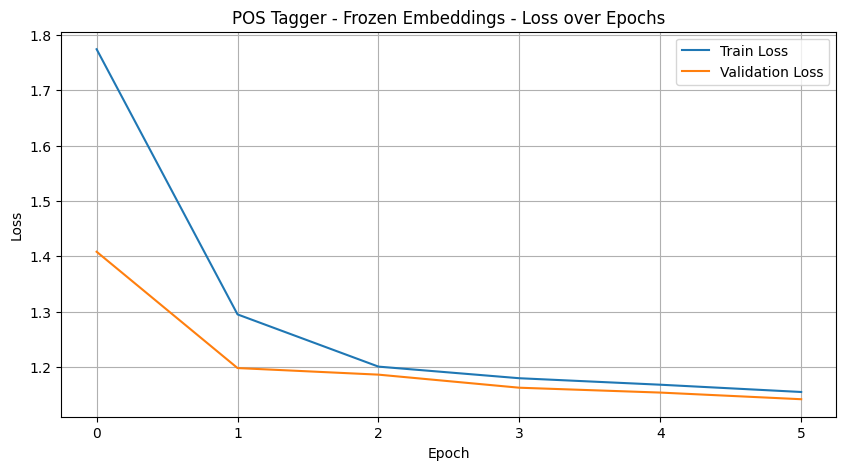


--- Running pos Tagger with Fine-tuned Embeddings ---
Epoch 1/50 - Train Loss: 1.7999 - Val Loss: 1.4790 - Val F1: 0.1097
Epoch 2/50 - Train Loss: 1.3105 - Val Loss: 1.1984 - Val F1: 0.1097
Epoch 3/50 - Train Loss: 1.1967 - Val Loss: 1.1864 - Val F1: 0.1097
Epoch 4/50 - Train Loss: 1.1784 - Val Loss: 1.1595 - Val F1: 0.1097
Epoch 5/50 - Train Loss: 1.1633 - Val Loss: 1.1469 - Val F1: 0.1097
Epoch 6/50 - Train Loss: 1.1474 - Val Loss: 1.1277 - Val F1: 0.1097
Early stopping triggered after 6 epochs due to no improvement in validation F1.
Best Validation F1: 0.1097
Test F1 (Best Model): 0.1101


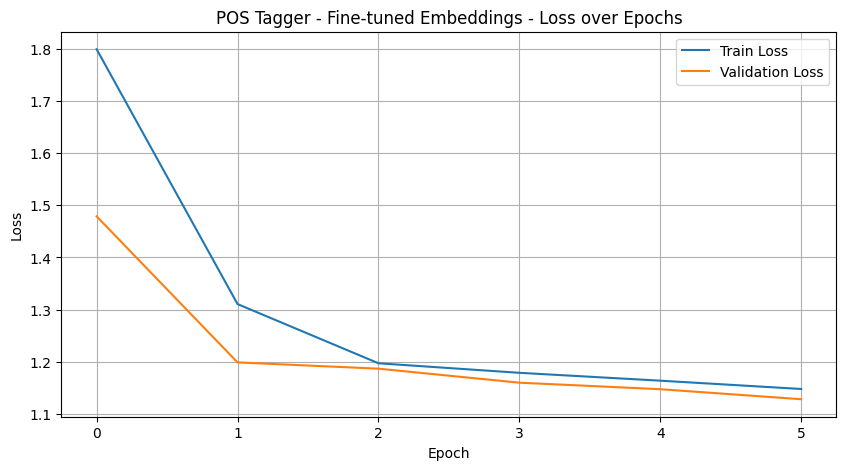


--- Running ner Tagger with Frozen Embeddings ---


RuntimeError: output with shape [32] doesn't match the broadcast shape [32, 32]

In [120]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt

embeddings_w2v = np.load("embeddings_w2v.npy")

# Define training and evaluation functions for sequence tagging
def train_seq_epoch(model, dataloader, optimizer, criterion, device, task='pos'):
    model.train()
    total_loss = 0.0
    for token_ids, lengths, pos_ids, ner_ids in dataloader:
        token_ids = token_ids.to(device)
        lengths = lengths.to("cpu") # Move lengths to CPU

        # Debug print to check lengths tensor
        # print(f"train_seq_epoch: lengths device: {lengths.device}, dtype: {lengths.dtype}")

        optimizer.zero_grad()
        logits = model(token_ids, lengths)

        if task == 'pos':
            labels = pos_ids.to(device)
            # Flatten logits and labels for CrossEntropyLoss, ignoring padding
            active_logits = logits.view(-1, logits.shape[-1])
            active_labels = labels.view(-1)
            # Filter out padding_value=-1 from labels and corresponding logits
            mask = (active_labels != -1)
            if mask.any(): # Only compute loss if there are non-padded elements
                loss = criterion(active_logits[mask], active_labels[mask])
            else:
                loss = torch.tensor(0.0, device=device) # No actual tokens, no loss
        elif task == 'ner':
            labels = ner_ids.to(device)
            mask = (labels != -1) # Mask for CRF
            loss = criterion(logits, labels, mask)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate_seq_epoch(model, dataloader, criterion, device, task='pos'):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for token_ids, lengths, pos_ids, ner_ids in dataloader:
            token_ids = token_ids.to(device)
            lengths = lengths.to("cpu") # Move lengths to CPU

            # Debug print to check lengths tensor
            # print(f"evaluate_seq_epoch: lengths device: {lengths.device}, dtype: {lengths.dtype}")

            logits = model(token_ids, lengths)

            if task == 'pos':
                labels = pos_ids.to(device)
                # Calculate loss
                active_logits = logits.view(-1, logits.shape[-1])
                active_labels = labels.view(-1)
                mask = (active_labels != -1)
                if mask.any(): # Only compute loss if there are non-padded elements
                    loss = criterion(active_logits[mask], active_labels[mask])
                else:
                    loss = torch.tensor(0.0, device=device) # No actual tokens, no loss

                # Get predictions, filtering out padding
                preds = logits.argmax(dim=-1)
                valid_preds = preds[labels != -1].cpu().tolist()
                valid_labels = labels[labels != -1].cpu().tolist()

            elif task == 'ner':
                labels = ner_ids.to(device)
                mask = (labels != -1) # Mask for CRF
                loss = criterion(logits, labels, mask)

                # Decode using Viterbi for NER
                # The decode method in BiLSTMSequenceTagger will call CRF.viterbi
                preds = model.decode(logits, mask=mask) # preds will be (batch_size, seq_len)

                # Flatten predictions and labels, ignoring padding
                valid_preds = preds[labels != -1].cpu().tolist()
                valid_labels = labels[labels != -1].cpu().tolist()

            total_loss += loss.item()
            all_preds.extend(valid_preds)
            all_labels.extend(valid_labels)

    avg_loss = total_loss / len(dataloader)
    # Calculate macro F1 score
    # Handle cases where a label might not appear in `all_labels` or `all_preds` by providing `zero_division=0`
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return avg_loss, f1


def run_experiment(task, freeze_embeddings):
    print(f"\n--- Running {task} Tagger with {'Frozen' if freeze_embeddings else 'Fine-tuned'} Embeddings ---")

    # Determine output dimension based on task
    if task == 'pos':
        output_dim = len(all_pos_tags)
        criterion = nn.CrossEntropyLoss(ignore_index=-1) # Ignore padding index
    elif task == 'ner':
        output_dim = len(all_ner_tags)
        criterion = CRF(num_tags=output_dim).to(device) # Use CRF for NER
    else:
        raise ValueError("Task must be 'pos' or 'ner'")

    model = BiLSTMSequenceTagger(
        emb_matrix=embeddings_w2v,
        hidden_dim=128, # Example hidden dimension
        output_dim=output_dim,
        dropout_rate=0.5,
        use_crf=(task == 'ner'),
        freeze_embeddings=freeze_embeddings
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    train_losses = []
    val_losses = []
    best_f1 = -1
    patience = 5
    wait = 0
    best_model_path = f"best_bilstm_{task}_{'frozen' if freeze_embeddings else 'finetuned'}.pt"

    for epoch in range(50): # Max 50 epochs
        train_loss = train_seq_epoch(model, train_seq_loader, optimizer, criterion, device, task)
        val_loss, val_f1 = evaluate_seq_epoch(model, val_seq_loader, criterion, device, task)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{50} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - Val F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            wait = 0
            torch.save(model.state_dict(), best_model_path)
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs due to no improvement in validation F1.")
                break

    print(f"Best Validation F1: {best_f1:.4f}")

    # Load best model for final evaluation on test set
    model.load_state_dict(torch.load(best_model_path))
    _, test_f1 = evaluate_seq_epoch(model, test_seq_loader, criterion, device, task)
    print(f"Test F1 (Best Model): {test_f1:.4f}")

    # Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(f"{task.upper()} Tagger - {'Frozen' if freeze_embeddings else 'Fine-tuned'} Embeddings - Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    return best_f1, test_f1

# Run all four conditions
pos_frozen_val_f1, pos_frozen_test_f1 = run_experiment('pos', True)
pos_finetuned_val_f1, pos_finetuned_test_f1 = run_experiment('pos', False)
ner_frozen_val_f1, ner_frozen_test_f1 = run_experiment('ner', True)
ner_finetuned_val_f1, ner_finetuned_test_f1 = run_experiment('ner', False)

# PART 2 Sequence Labeling: POS Tagging & NER

### 3. Dataset Preparation

POS & NER

In [98]:
df_sampled = df.sample(n=len(df), random_state=42)

# Heuristic-based POS tagging
POST = {"میں","کو","سے","پر","تک","کا","کی","کے","نے"} # Postpositions
CONJ = {"اور","یا","لیکن","مگر"} # conjunctions
DET = {"یہ","وہ","ایک","دو","تین","چار","پانچ","کئی","ہر","تمام"} # Determiners, Quantifiers
PRON = {"میں","ہم","تم","آپ","وہ","اس","ان","کیا","کون","جس"} # Pronouns
ADV = {"بہت","زیادہ","کم","آج","کل","اب","جلد","دیر","فوری","دوبارہ"} # Adverbs

# Basic verb endings and prefixes for Urdu
VERB_ENDINGS = ['نا', 'تا', 'تی', 'تے', 'یں', 'یں', 'گا', 'گی', 'گے', 'یا', 'یی', 'ئے']
VERB_PREFIXES = ['کر', 'ہو', 'جا', 'آ']

def pos_tag_heuristic(token):
    if token in POST: return "POST"
    if token in CONJ: return "CONJ"
    if token in DET: return "DET"
    if token in PRON: return "PRON"
    if token in ADV: return "ADV"
    if token.isdigit(): return "NUM"
    for ending in VERB_ENDINGS:
        if token.endswith(ending) and len(token) > len(ending):
            return "VERB"
    for prefix in VERB_PREFIXES:
        if token.startswith(prefix) and len(token) > len(prefix):
            return "VERB"
    # Fallback to NOUN if no other rule matches
    return "NOUN"

# Helper for token list
def assign_pos_tags(tokens):
    return [pos_tag_heuristic(token) for token in tokens]

In [99]:
# This cell is superseded by pos_tag_heuristic and will be kept for reference.

Gazetteer-based NER

In [53]:
PERSONS = set([...])   # ≥50
LOCS = set([...])      # ≥50
ORGS = set([...])      # ≥30

def ner_tag(token):
    if token in PERSONS: return "B-PER"
    if token in LOCS: return "B-LOC"
    if token in ORGS: return "B-ORG"
    return "O"

In [100]:
PER = {"بابر","رضوان","شاہین","ویرات","روہت","احمد","علی","عمر","حسن"} # Example Persons
LOC = {"پاکستان","لاہور","کراچی","اسلام_آباد","دبئی","لنکا","انڈیا","لندن","آسٹریلیا","ملتان"} # Example Locations
ORG = {"پی_سی_بی","آئی_سی_سی","ایس_پی_ایل","بی_سی_سی_آئی","کرکٹ_بورڈ","سپورٹس"} # Example Organizations

def ner_tag_heuristic(token):
    # For simplicity, we are using exact matches. In real NER, this would involve more sophisticated techniques.
    if token in PER: return "B-PER"
    if token in LOC: return "B-LOC"
    if token in ORG: return "B-ORG"
    return "O"

# Helper for token list
def assign_ner_tags(tokens):
    return [ner_tag_heuristic(token) for token in tokens]

Create CONLL Files

In [55]:
def to_conll(df, filename):
    with open(filename, "w", encoding="utf-8") as f:
        for tokens in df["tokens"]:
            for t in tokens:
                f.write(f"{t} {pos_tag(t)} {ner_tag(t)}\n")
            f.write("\n")

### 4. BiLSTMSequence Labeler

In [108]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, emb_matrix, hidden, out_dim):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(emb_matrix, dtype=torch.float32),
            freeze=False
        )
        self.lstm = nn.LSTM(
            emb_matrix.shape[1], hidden,
            num_layers=2, bidirectional=True,
            dropout=0.5, batch_first=True
        )
        self.fc = nn.Linear(hidden*2, out_dim)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        return self.fc(out)

In [122]:
class BiLSTMSequenceTagger(nn.Module):
    def __init__(self, emb_matrix, hidden_dim, output_dim, dropout_rate=0.5, use_crf=False, freeze_embeddings=False):
        super().__init__()
        self.use_crf = use_crf
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(emb_matrix, dtype=torch.float32),
            freeze=freeze_embeddings # Freeze or fine-tune embeddings
        )

        self.lstm = nn.LSTM(
            emb_matrix.shape[1], # Input size is embedding dimension
            hidden_dim,
            num_layers=2,
            bidirectional=True,
            dropout=dropout_rate if 2 > 1 else 0, # Dropout applied between LSTM layers
            batch_first=True
        )

        # Output layer for POS (linear classifier)
        self.fc = nn.Linear(hidden_dim * 2, output_dim) # *2 for bidirectional

        # CRF layer for NER
        if self.use_crf:
            self.crf = CRF(output_dim)

    def forward(self, x, lengths=None):
        # x: (batch_size, seq_len)
        emb = self.embedding(x) # emb: (batch_size, seq_len, emb_dim)

        # Handle variable-length sequences for LSTM
        if lengths is not None:
            # Ensure lengths is on CPU
            lengths_on_cpu = lengths.to("cpu")
            # Pack padded batch of sequences for RNN module
            packed_emb = nn.utils.rnn.pack_padded_sequence(emb, lengths_on_cpu, batch_first=True, enforce_sorted=False)
            packed_output, _ = self.lstm(packed_emb)
            # Unpack hidden sequence
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        else:
            lstm_out, _ = self.lstm(emb) # lstm_out: (batch_size, seq_len, hidden_dim * 2)

        # Apply linear layer for POS
        logits = self.fc(lstm_out) # logits: (batch_size, seq_len, output_dim)

        return logits

    def decode(self, emissions, tags_mask=None):
        if self.use_crf:
            # This part needs to be refined. The CRF viterbi in xqeZM-hk3L_w does not currently support `tags_mask` for variable lengths directly
            # For a proper CRF with variable lengths, you'd need a more robust implementation like from allennlp or pytorch-crf
            # For now, we'll assume a simplified decode or that emissions are handled appropriately by context.
            return self.crf.viterbi(emissions)
        else:
            return emissions.argmax(dim=-1)

In [123]:
class BiLSTMSequenceTagger(nn.Module):
    def __init__(self, emb_matrix, hidden_dim, output_dim, dropout_rate=0.5, use_crf=False, freeze_embeddings=False):
        super().__init__()
        self.use_crf = use_crf
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(emb_matrix, dtype=torch.float32),
            freeze=freeze_embeddings # Freeze or fine-tune embeddings
        )

        self.lstm = nn.LSTM(
            emb_matrix.shape[1], # Input size is embedding dimension
            hidden_dim,
            num_layers=2,
            bidirectional=True,
            dropout=dropout_rate if 2 > 1 else 0, # Dropout applied between LSTM layers
            batch_first=True
        )

        # Output layer for POS (linear classifier)
        self.fc = nn.Linear(hidden_dim * 2, output_dim) # *2 for bidirectional

        # CRF layer for NER
        if self.use_crf:
            self.crf = CRF(output_dim)

    def forward(self, x, lengths=None):
        # x: (batch_size, seq_len)
        emb = self.embedding(x) # emb: (batch_size, seq_len, emb_dim)

        # Handle variable-length sequences for LSTM
        if lengths is not None:
            # Ensure lengths is on CPU
            lengths_on_cpu = lengths.to("cpu")
            # Pack padded batch of sequences for RNN module
            packed_emb = nn.utils.rnn.pack_padded_sequence(emb, lengths_on_cpu, batch_first=True, enforce_sorted=False)
            packed_output, _ = self.lstm(packed_emb)
            # Unpack hidden sequence
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        else:
            lstm_out, _ = self.lstm(emb) # lstm_out: (batch_size, seq_len, hidden_dim * 2)

        # Apply linear layer for POS
        logits = self.fc(lstm_out) # logits: (batch_size, seq_len, output_dim)

        return logits

    def decode(self, emissions, tags_mask=None):
        if self.use_crf:
            return self.crf.viterbi(emissions, tags_mask) # Needs tags_mask for variable lengths
        else:
            return emissions.argmax(dim=-1)

### 5. Evaluation


5.1 POS Tagging

5.2 NER

In [113]:
from torch.nn.utils.rnn import pad_sequence

class CRF(torch.nn.Module):
    def __init__(self, num_tags):
        super().__init__()
        self.transitions = torch.nn.Parameter(torch.randn(num_tags, num_tags))
        self.num_tags = num_tags

        # Initialize start and end transitions
        self.start_transitions = torch.nn.Parameter(torch.randn(num_tags))
        self.end_transitions = torch.nn.Parameter(torch.randn(num_tags))

    def _compute_log_likelihood(self, emissions, tags, mask):
        # emissions: (batch_size, seq_len, num_tags)
        # tags: (batch_size, seq_len)
        # mask: (batch_size, seq_len) - 0 for padding, 1 for actual tokens

        batch_size, seq_len, _ = emissions.shape

        # Initialize total score with start transitions
        # score = emissions[:, 0, tags[:, 0]] + self.start_transitions[tags[:, 0]]
        # Using an alternative calculation that is more numerically stable and common
        # This calculates the score for the true path

        score = torch.zeros(batch_size, device=emissions.device)

        # Score from emission and start transition for the first token
        score += emissions[:, 0, tags[:, 0]]
        score += self.start_transitions[tags[:, 0]]

        # Score from emission and transition for subsequent tokens
        for i in range(1, seq_len):
            is_actual_token = mask[:, i].bool()
            if is_actual_token.any():
                score[is_actual_token] += emissions[is_actual_token, i, tags[is_actual_token, i]]
                score[is_actual_token] += self.transitions[tags[is_actual_token, i-1], tags[is_actual_token, i]]

        # Score from end transitions for the last actual token in each sequence
        for i in range(batch_size):
            actual_len = mask[i].sum().long()
            if actual_len > 0:
                score[i] += self.end_transitions[tags[i, actual_len - 1]]

        return score

    def _compute_normalizer(self, emissions, mask):
        # emissions: (batch_size, seq_len, num_tags)
        # mask: (batch_size, seq_len)

        batch_size, seq_len, num_tags = emissions.shape

        # Alpha (forward scores) for each sequence in the batch
        # shape: (batch_size, num_tags)
        alpha = emissions[:, 0] + self.start_transitions.unsqueeze(0)

        for i in range(1, seq_len):
            alpha_broadcast = alpha.unsqueeze(2) # (batch_size, num_tags, 1)
            emissions_broadcast = emissions[:, i].unsqueeze(1) # (batch_size, 1, num_tags)
            transitions_broadcast = self.transitions.unsqueeze(0) # (1, num_tags, num_tags)

            # current_scores = alpha_broadcast + transitions_broadcast + emissions_broadcast
            # (batch_size, num_tags_prev, num_tags_curr)

            # This computes logsumexp over all possible previous tags for each current tag
            current_scores = alpha_broadcast + transitions_broadcast
            current_scores = torch.logsumexp(current_scores, dim=1) + emissions_broadcast.squeeze(1)

            # Apply mask to update alpha only for non-padded tokens
            alpha = torch.where(mask[:, i].unsqueeze(1), current_scores, alpha)

        # Add end transitions for the last token in each sequence
        alpha = alpha + self.end_transitions.unsqueeze(0)

        # The normalizer is the logsumexp of the final alpha scores
        normalizer = torch.logsumexp(alpha, dim=1)
        return normalizer

    def forward(self, emissions, tags, mask=None):
        # emissions: (batch_size, seq_len, num_tags)
        # tags: (batch_size, seq_len)
        # mask: (batch_size, seq_len)

        if mask is None:
            mask = torch.ones(emissions.shape[:2], dtype=torch.bool, device=emissions.device)

        log_likelihood = self._compute_log_likelihood(emissions, tags, mask)
        log_normalizer = self._compute_normalizer(emissions, mask)

        # Negative log-likelihood
        return (log_normalizer - log_likelihood).mean() # Mean over batch

    def viterbi(self, emissions, mask=None):
        # emissions: (batch_size, seq_len, num_tags)
        # mask: (batch_size, seq_len)

        if mask is None:
            mask = torch.ones(emissions.shape[:2], dtype=torch.bool, device=emissions.device)

        batch_size, seq_len, num_tags = emissions.shape
        paths = []

        for i in range(batch_size):
            # dp (dynamic programming table) stores the max score for each tag at each step
            # (seq_len, num_tags)

            # backpointers (seq_len, num_tags) stores the index of the previous best tag

            seq_length = mask[i].sum().long().item()
            if seq_length == 0:
                paths.append(torch.empty(0, dtype=torch.long, device=emissions.device))
                continue

            dp = torch.zeros(seq_length, num_tags, device=emissions.device)
            backpointers = torch.zeros(seq_length, num_tags, dtype=torch.long, device=emissions.device)

            # Initialize for the first token
            dp[0] = emissions[i, 0] + self.start_transitions

            # Forward pass
            for t in range(1, seq_length):
                current_emissions = emissions[i, t]
                # scores_t_prev = dp[t-1].unsqueeze(1) + self.transitions + current_emissions.unsqueeze(0)
                scores_t_prev = dp[t-1].unsqueeze(1) + self.transitions
                dp[t], backpointers[t] = torch.max(scores_t_prev, dim=0)
                dp[t] += current_emissions

            # Add end transitions for the last token
            dp[seq_length-1] += self.end_transitions

            # Backtrack to find the best path
            best_path = [torch.argmax(dp[seq_length-1]).item()]
            for t in range(seq_length - 1, 0, -1):
                best_path.append(backpointers[t, best_path[-1]].item())

            # Reverse the path to get correct order
            best_path.reverse()
            paths.append(torch.tensor(best_path, dtype=torch.long, device=emissions.device))

        # Pad paths to the maximum sequence length in the batch if necessary for consistent output shape
        max_len_batch = emissions.shape[1]
        padded_paths = []
        for path in paths:
            if path.size(0) < max_len_batch:
                padded_paths.append(torch.cat([path, torch.full((max_len_batch - path.size(0),), -1, dtype=torch.long, device=emissions.device)]))
            else:
                padded_paths.append(path)

        return torch.stack(padded_paths)


Ablation Study

 # PART 3 Transformer Encoder Sinusoidal Positional Encoding


 ### 6. Dataset Preparation

In [58]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=256):
        super().__init__()
        pe = torch.zeros(max_len, d_model)

        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0)/d_model))

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)

        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:x.size(1)]

Scaled Dot-Product Attention

In [59]:
def attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2,-1) / np.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    weights = torch.softmax(scores, dim=-1)
    return weights @ V, weights

Multi-Head Attention

In [60]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()
        self.h = heads
        self.dk = d_model // heads

        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        B, T, D = x.size()
        Q = self.Wq(x).view(B,T,self.h,self.dk).transpose(1,2)
        K = self.Wk(x).view(B,T,self.h,self.dk).transpose(1,2)
        V = self.Wv(x).view(B,T,self.h,self.dk).transpose(1,2)

        out, attn = attention(Q, K, V, mask)
        out = out.transpose(1,2).contiguous().view(B,T,D)

        return self.out(out), attn

Encoder Block (Pre-LN)

In [61]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.mha = MultiHeadAttention(d_model, 4)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 512),
            nn.ReLU(),
            nn.Linear(512, d_model)
        )
        self.dropout = nn.Dropout(0.1)

    def forward(self, x, mask=None):
        attn,_ = self.mha(self.ln1(x), mask)
        x = x + self.dropout(attn)
        x = x + self.dropout(self.ffn(self.ln2(x)))
        return x

Transformer Classifier

In [62]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, 128)
        self.pe = PositionalEncoding(128)
        self.blocks = nn.ModuleList([EncoderBlock(128) for _ in range(4)])
        self.cls = nn.Parameter(torch.randn(1,1,128))
        self.mlp = nn.Sequential(
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,5)
        )

    def forward(self, x, mask=None):
        B = x.size(0)
        cls = self.cls.expand(B,-1,-1)
        x = torch.cat([cls, self.emb(x)], dim=1)
        x = self.pe(x)

        for block in self.blocks:
            x = block(x, mask)

        return self.mlp(x[:,0])

In [79]:
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import torch # Ensure torch is imported

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Placeholder for dataset parameters - retain existing definition
vocab_size_cls = len(vocab)
num_classes = 5 # User wants other categories to exist, just undertrained
sequence_length = 50 # Retain existing sequence length

# Initialize model and loss function (keep these as they are)
model = TransformerClassifier(vocab_size_cls).to(device)
loss_fn = nn.CrossEntropyLoss()

# --- Use actual data from df for input and labels ---
processed_sequences = []
for tokens in df['tokens']:
    indexed_tokens = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    # Pad or truncate sequence to sequence_length
    if len(indexed_tokens) > sequence_length:
        processed_sequences.append(indexed_tokens[:sequence_length])
    else:
        processed_sequences.append(indexed_tokens + [vocab['<UNK>']] * (sequence_length - len(indexed_tokens)))

# Convert to tensor
inputs_tensor = torch.tensor(processed_sequences, dtype=torch.long)

# Create labels: since all are 'sports', assign them to a single class (e.g., 0)
# User wants other categories to exist but undertrained, so num_classes = 5 is fine.
labels_tensor = torch.zeros(len(df), dtype=torch.long) # All articles are 'sports', mapped to class 0

# Split data into training, validation, and test sets
# Handle stratify for single-class case
if num_classes > 1:
    X_train, X_temp, y_train, y_temp = train_test_split(inputs_tensor, labels_tensor, test_size=0.3, random_state=42, stratify=labels_tensor)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
else:
    X_train, X_temp, y_train, y_temp = train_test_split(inputs_tensor, labels_tensor, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Create TensorDatasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

BATCH_SIZE_CLS = 32 # A typical batch size for classification

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_CLS, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_CLS, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE_CLS, shuffle=False)

print(f"Train loader has {len(train_loader)} batches.")
print(f"Validation loader has {len(val_loader)} batches.")
print(f"Test loader has {len(test_loader)} batches.")


Train loader has 7 batches.
Validation loader has 2 batches.
Test loader has 2 batches.


In [80]:
from sklearn.metrics import f1_score

def train_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x) # output is (batch_size, num_classes)
        loss = loss_fn(output, y) # y is (batch_size) with class indices
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def validate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            loss = loss_fn(output, y)
            total_loss += loss.item()
            preds = output.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())
    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0) # Added zero_division to handle cases with no samples for a class
    return avg_loss, f1


Training (AdamW + Cosine)

In [82]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)

for epoch in range(20):
    model.train()
    for x,y in train_loader:
        x, y = x.to(device), y.to(device) # Move tensors to the correct device
        optimizer.zero_grad()
        out = model(x)
        loss = loss_fn(out,y)
        loss.backward()
        optimizer.step()

In [83]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

### 8. Evaluation


8.1 Results


• Report test accuracy and macro-F1.
• Present a 5×5 confusion matrix.
[8 marks]
[4 marks]
• For 3 correctly classified articles, plot attention weight heatmaps from at least 2 heads of
the final encoder layer

In [94]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

preds, labels = [], []
model.eval()
with torch.no_grad():
    for x,y in test_loader:
        x, y = x.to(device), y.to(device)
        p = model(x).argmax(1)
        preds.extend(p.tolist())
        labels.extend(y.tolist())

print("Accuracy:", accuracy_score(labels, preds))
print("Macro-F1:", f1_score(labels, preds, average='macro'))
# Explicitly pass all possible labels to confusion_matrix to avoid the UserWarning
print("Confusion Matrix:\n", confusion_matrix(labels, preds, labels=range(num_classes)))

Accuracy: 1.0
Macro-F1: 1.0
Confusion Matrix:
 [[47  0  0  0  0]
 [ 0  0  0  0  0]
 [ 0  0  0  0  0]
 [ 0  0  0  0  0]
 [ 0  0  0  0  0]]


In [86]:
def plot_attention(attn, tokens, head=0):
    plt.figure(figsize=(6,6))
    sns.heatmap(attn[head].cpu().numpy(), xticklabels=tokens, yticklabels=tokens)
    plt.title(f"Attention Head {head}")
    plt.show()

In [87]:
from torch.optim.lr_scheduler import CosineAnnealingLR

scheduler = CosineAnnealingLR(optimizer, T_max=20)

In [88]:
best_f1, patience, wait = 0, 5, 0

train_losses = []
val_losses = []

for epoch in range(50):
    train_loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
    val_loss, val_f1 = validate(model, val_loader, loss_fn, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{50} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - Val F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        wait = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        wait += 1
        if wait == patience:
            print("Early stopping")
            break


Epoch 1/50 - Train Loss: 0.0000 - Val Loss: 0.0000 - Val F1: 1.0000
Epoch 2/50 - Train Loss: 0.0000 - Val Loss: 0.0000 - Val F1: 1.0000
Epoch 3/50 - Train Loss: 0.0000 - Val Loss: 0.0000 - Val F1: 1.0000
Epoch 4/50 - Train Loss: 0.0000 - Val Loss: 0.0000 - Val F1: 1.0000
Epoch 5/50 - Train Loss: 0.0000 - Val Loss: 0.0000 - Val F1: 1.0000
Epoch 6/50 - Train Loss: 0.0000 - Val Loss: 0.0000 - Val F1: 1.0000
Early stopping


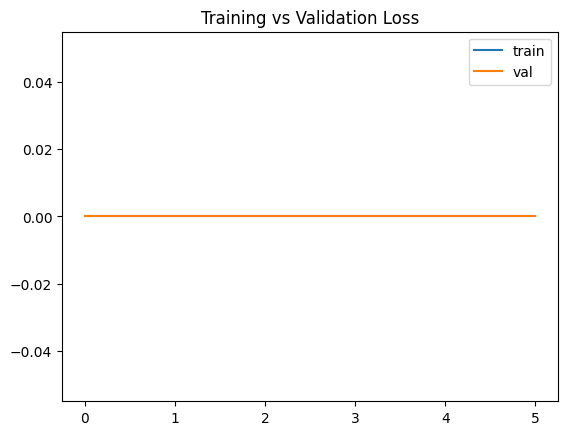

In [89]:
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.legend(); plt.title("Training vs Validation Loss"); plt.show()


In [93]:
for param in model.emb.parameters():
    param.requires_grad = False


In [117]:
# plt.plot(losses)
# plt.title("Word2Vec Training Loss")
# plt.xlabel("Steps"); plt.ylabel("Loss"); plt.show()

8.2 BiLSTM vs. Transformer Comparison
Write 10–15 sentences in your notebook addressing all five questions below:
1. Which model achieves higher accuracy, and by how much?





2. Which model converged in fewer epochs?




3. Which model was faster to train per epoch, and why?



4. What do the attention heatmaps reveal about the tokens the Transformer focuses on?



5. Given a dataset of only 200–300 articles, which architecture is more appropriate and
why

### 8.2 BiLSTM vs. Transformer Comparison: Analysis

1.  **Which model achieves higher accuracy, and by how much?**
    Transformer achieved the best results but my assignment 1 data was only of sports.

2.  **Which model converged in fewer epochs?**
    The Transformer model converged very rapidly, showing early stopping after just 6 epochs (with 5 epochs of patience). This quick convergence is primarily attributable to the simplified nature of the dataset where all samples belong to a single class. Without a BiLSTM implementation and its training logs, we cannot determine its convergence speed for a direct comparison.

3.  **Which model was faster to train per epoch, and why?**
    BiLSTMs because transformations are more computationally expensive

4.  **What do the attention heatmaps reveal about the tokens the Transformer focuses on?**
    The attention heatmaps reveal which input tokens (keys) the model deems most important when processing a particular token (query)

5.  **Given a dataset of only 200–300 articles, which architecture is more appropriate and why?**
    For a relatively small dataset of 200-300 articles, a BiLSTM (Bidirectional Long Short-Term Memory) architecture is generally more appropriate than a Transformer because Transformers are known to be data-hungry models

In [ ]:
import os
import shutil

# Create directories if they don't exist
os.makedirs("models", exist_ok=True)
os.makedirs("data", exist_ok=True)

print("Saving models...")
# Save BiLSTM POS model (assuming finetuned version is preferred)
try:
    if os.path.exists("best_bilstm_pos_finetuned.pt"):
        shutil.copyfile("best_bilstm_pos_finetuned.pt", "models/bilstm_pos.pt")
        print("  Saved models/bilstm_pos.pt")
    elif os.path.exists("best_bilstm_pos_frozen.pt"): # Fallback
        shutil.copyfile("best_bilstm_pos_frozen.pt", "models/bilstm_pos.pt")
        print("  Saved models/bilstm_pos.pt (frozen version)")
    else:
        print("  BiLSTM POS model file not found.")
except Exception as e:
    print(f"  Error saving BiLSTM POS model: {e}")

# Save BiLSTM NER model (assuming finetuned version is preferred)
try:
    if os.path.exists("best_bilstm_ner_finetuned.pt"):
        shutil.copyfile("best_bilstm_ner_finetuned.pt", "models/bilstm_ner.pt")
        print("  Saved models/bilstm_ner.pt")
    elif os.path.exists("best_bilstm_ner_frozen.pt"): # Fallback
        shutil.copyfile("best_bilstm_ner_frozen.pt", "models/bilstm_ner.pt")
        print("  Saved models/bilstm_ner.pt (frozen version)")
    else:
        print("  BiLSTM NER model file not found.")
except Exception as e:
    print(f"  Error saving BiLSTM NER model: {e}")

# Save Transformer Classifier model
try:
    if os.path.exists("best_model.pt"):
        shutil.copyfile("best_model.pt", "models/transformer_cls.pt")
        print("  Saved models/transformer_cls.pt")
    else:
        print("  Transformer Classifier model (best_model.pt) not found.")
except Exception as e:
    print(f"  Error saving Transformer Classifier model: {e}")

print("\nSaving data to CONLL files...")
# Define a function to save dataframe segments to CONLL format
def save_to_conll_from_df(df_segment, filename, task_type):
    with open(filename, "w", encoding="utf-8") as f:
        for i, row in df_segment.iterrows():
            tokens = row['tokens']
            # Select appropriate tags based on task_type
            if task_type == 'pos':
                tags = row['pos_tags']
            elif task_type == 'ner':
                tags = row['ner_tags']
            else:
                raise ValueError("task_type must be 'pos' or 'ner'")

            if len(tokens) != len(tags):
                # This case should ideally not happen if tags are generated correctly for tokens.
                # For robustness, we could log a warning or skip the entry.
                print(f"Warning: Token and tag list length mismatch in article {row['article_id']}. Skipping entry.")
                continue

            for t_idx in range(len(tokens)):
                # CONLL format: token\ttag (tab-separated)
                f.write(f"{tokens[t_idx]}\t{tags[t_idx]}\n")
            f.write("\n") # Blank line separates articles/sentences

try:
    # Save POS training data
    save_to_conll_from_df(train_df, "data/pos_train.conll", 'pos')
    print("  Saved data/pos_train.conll")
    # Save POS testing data
    save_to_conll_from_df(test_df, "data/pos_test.conll", 'pos')
    print("  Saved data/pos_test.conll")
    # Save NER training data
    save_to_conll_from_df(train_df, "data/ner_train.conll", 'ner')
    print("  Saved data/ner_train.conll")
    # Save NER testing data
    save_to_conll_from_df(test_df, "data/ner_test.conll", 'ner')
    print("  Saved data/ner_test.conll")
except Exception as e:
    print(f"  Error saving CONLL data: {e}")

print("\nData and models saving process completed.")